<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


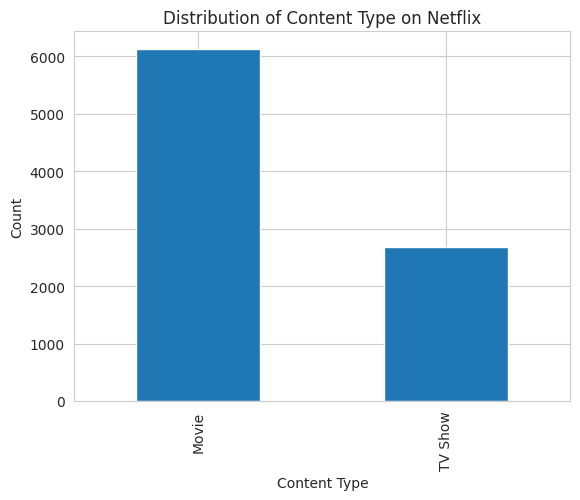

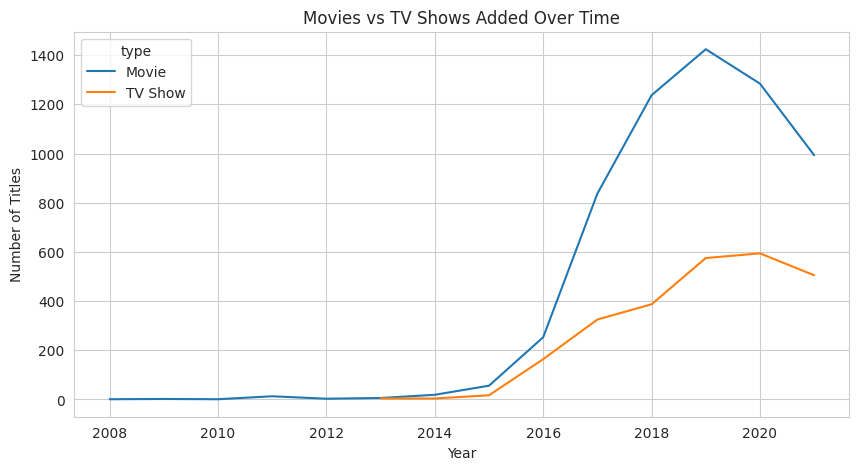

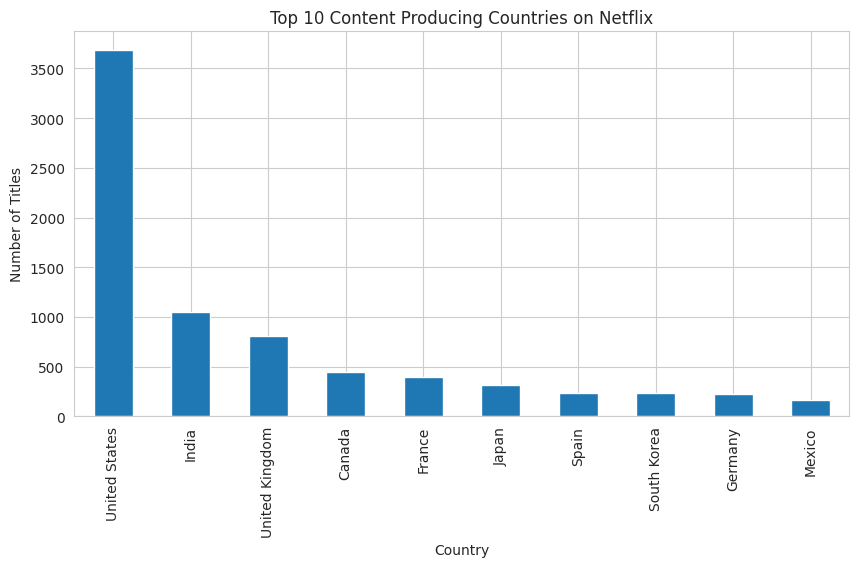

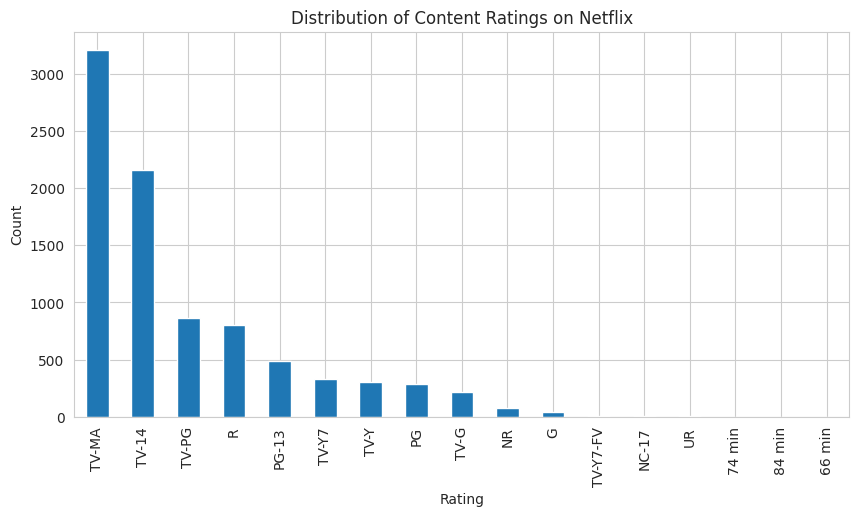

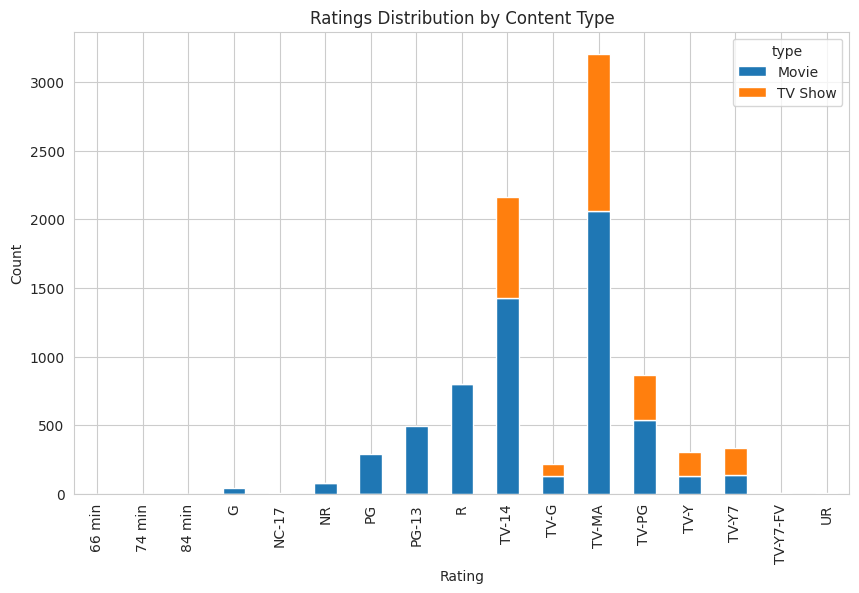

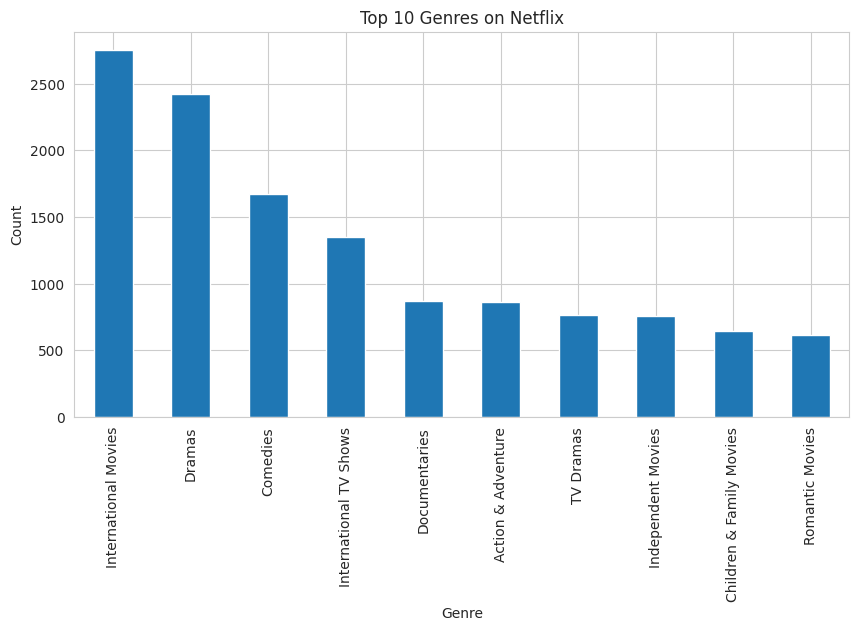

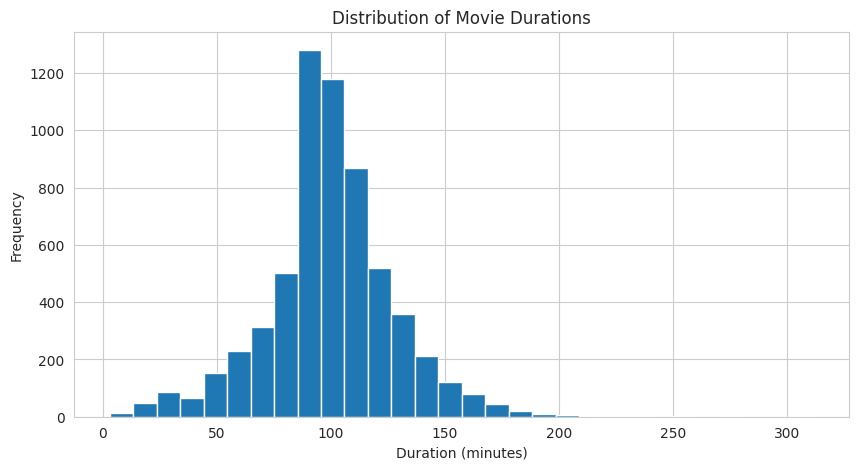

In [14]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


# 2. Load dataset
df = pd.read_csv("netflix_titles.csv")


# 3. Initial data exploration
df.head()
df.shape
df.info()
df.isnull().sum()


# 4. Data cleaning & feature engineering

# Drop rows with missing essential values
df = df.dropna(subset=["type", "rating"])

# Convert date_added to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract year added
df["year_added"] = df["date_added"].dt.year

# Extract numeric duration and unit
df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([a-zA-Z]+)")


# ==============================
# Objective 1: Movies vs TV Shows
# ==============================

# Distribution of content type
type_counts = df["type"].value_counts()

plt.figure()
type_counts.plot(kind="bar")
plt.title("Distribution of Content Type on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

# Trend over time
trend = df.groupby(["year_added", "type"]).size().unstack()

trend.plot(figsize=(10, 5))
plt.title("Movies vs TV Shows Added Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()


# ==============================
# Objective 3: Geographic Distribution
# ==============================

# Handle multiple countries
country_df = df.dropna(subset=["country"]).copy() # Added .copy() to resolve SettingWithCopyWarning
country_df["country"] = country_df["country"].str.split(", ")
country_df = country_df.explode("country")

top_countries = country_df["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar")
plt.title("Top 10 Content Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()


# ==============================
# Objective 4: Audience Targeting (Ratings)
# ==============================

# Rating distribution
rating_counts = df["rating"].value_counts()

plt.figure(figsize=(10, 5))
rating_counts.plot(kind="bar")
plt.title("Distribution of Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Ratings by content type
rating_type = pd.crosstab(df["rating"], df["type"])

rating_type.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Ratings Distribution by Content Type")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


# ==============================
# Objective 5: Genre & Duration Insights
# ==============================

# Genre analysis
genre_df = df.dropna(subset=["listed_in"])
genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")
genre_df = genre_df.explode("listed_in")

top_genres = genre_df["listed_in"].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_genres.plot(kind="bar")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()


# Movie duration analysis
movies = df[df["type"] == "Movie"]

plt.figure(figsize=(10, 5))
plt.hist(movies["duration_value"].dropna(), bins=30)
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()